### Import Necessary Libraries


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from scipy.interpolate import RegularGridInterpolator
from scipy.ndimage import gaussian_filter

import cartopy.crs as ccrs
import cartopy.feature as cfeature

from matplotlib.colors import Normalize, TwoSlopeNorm

from sklearn.linear_model import LinearRegression


### Read in CSV From ESWMF Reanalysis Data

In [4]:
# Step 1: Read in aggregated data.
# -----------------------------
df = pd.read_csv('combined_output.csv')
print(df.head)

<bound method NDFrame.head of         Year    Lat    Lon  days_below_55F  days_below_32F  days_below_28F  \
0       1956  35.00 -95.00             190              50              26   
1       1956  35.00 -94.75             187              45              24   
2       1956  35.00 -94.50             190              46              25   
3       1956  35.00 -94.25             194              50              25   
4       1956  35.00 -94.00             193              52              26   
...      ...    ...    ...             ...             ...             ...   
107915  2021  25.25 -80.75               3               0               0   
107916  2021  25.00 -78.00               0               0               0   
107917  2021  24.75 -78.00               1               0               0   
107918  2021  24.50 -78.00               0               0               0   
107919  2021  24.00 -77.75               0               0               0   

        days_below_26F  annual_mi

### Project Each Metric 25 Years Into the Future Using Linear Regression and Visualize The Results of the Global Means

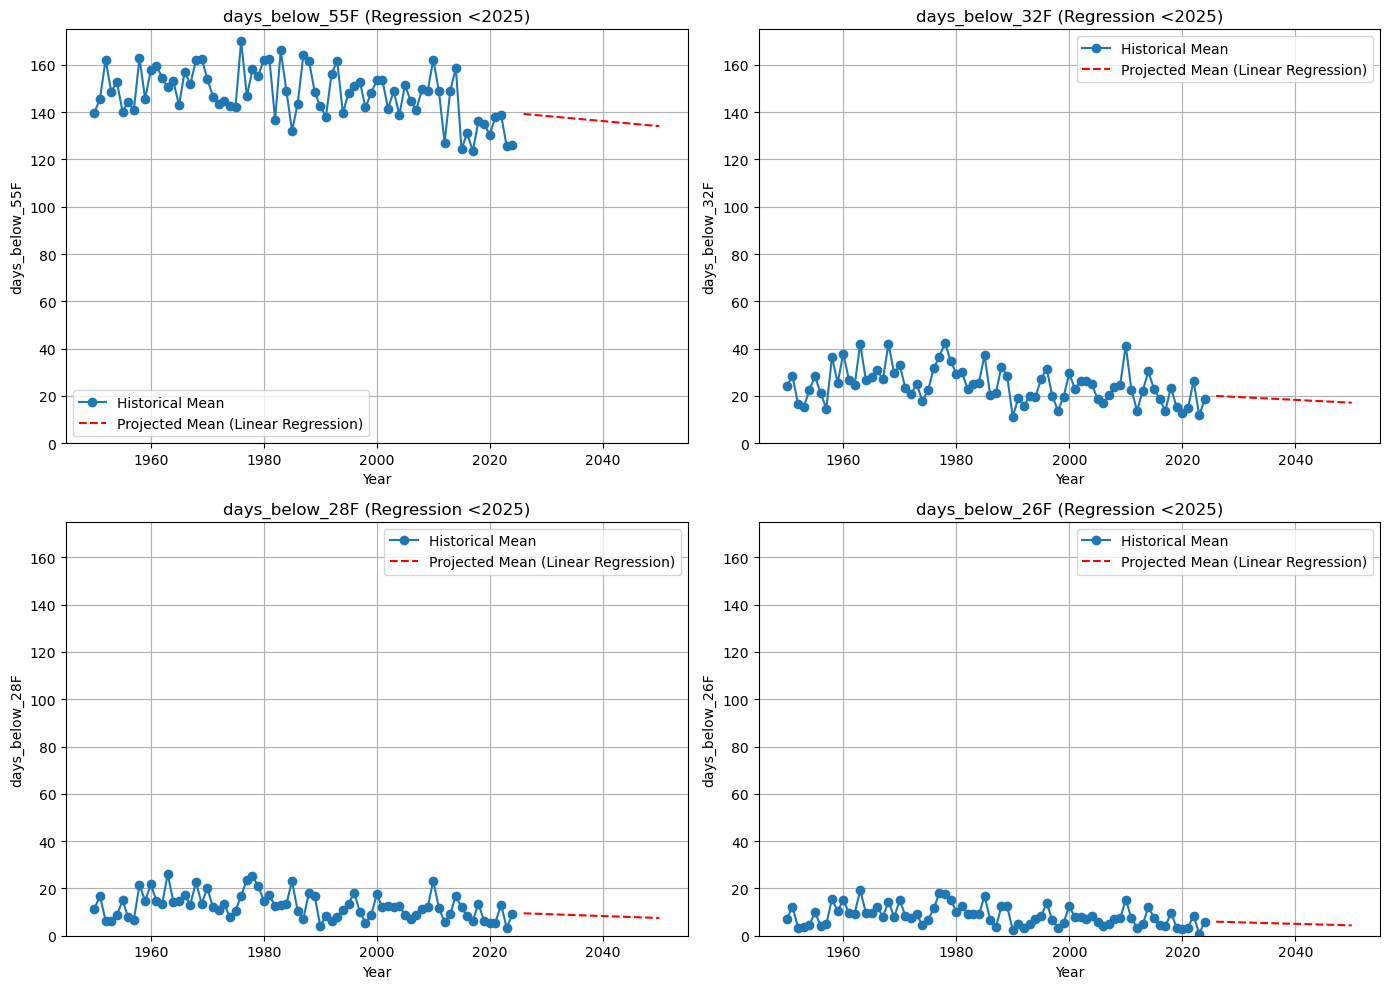

In [6]:
# Step 2: Define metrics and future years
# -----------------------------
metrics = ['days_below_55F','days_below_32F','days_below_28F','days_below_26F']
future_years = np.arange(2026, 2051).reshape(-1,1)

# -----------------------------
# Step 3: Create 2x2 subplot layout
# -----------------------------
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()  # flatten to 1D array for easy iteration

for i, metric in enumerate(metrics):
    ax = axes[i]
    
    # Compute mean per year across all locations
    yearly_mean = df.groupby('Year')[metric].mean().reset_index()
    
    # Exclude 2025 since it's incomplete
    yearly_mean = yearly_mean[yearly_mean['Year'] < 2025]
    
    X = yearly_mean[['Year']].values
    y = yearly_mean[metric].values
    
    # Fit regression
    model = LinearRegression()
    model.fit(X, y)
    
    # Predict future years (2026–2050)
    y_future = model.predict(future_years)
    
    # Plot with markers
    ax.plot(yearly_mean['Year'], yearly_mean[metric], 'o-', label='Historical Mean')
    ax.plot(future_years, y_future, 'r--', label='Projected Mean (Linear Regression)')
    
    # Formatting
    ax.set_title(f"{metric} (Regression <2025)")
    ax.set_xlabel("Year")
    ax.set_ylabel(metric)
    ax.set_ylim(0, 175)  # enforce consistent scale
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()


### Plot Days Below 55 by Time Period Including Linear Regression Prediction

/var/folders/3p/cs07b9rs4vx__r1rpt2kvmn00000gn/T/ipykernel_65498/489501180.py:63: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(forecast)
/var/folders/3p/cs07b9rs4vx__r1rpt2kvmn00000gn/T/ipykernel_65498/489501180.py:110: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])


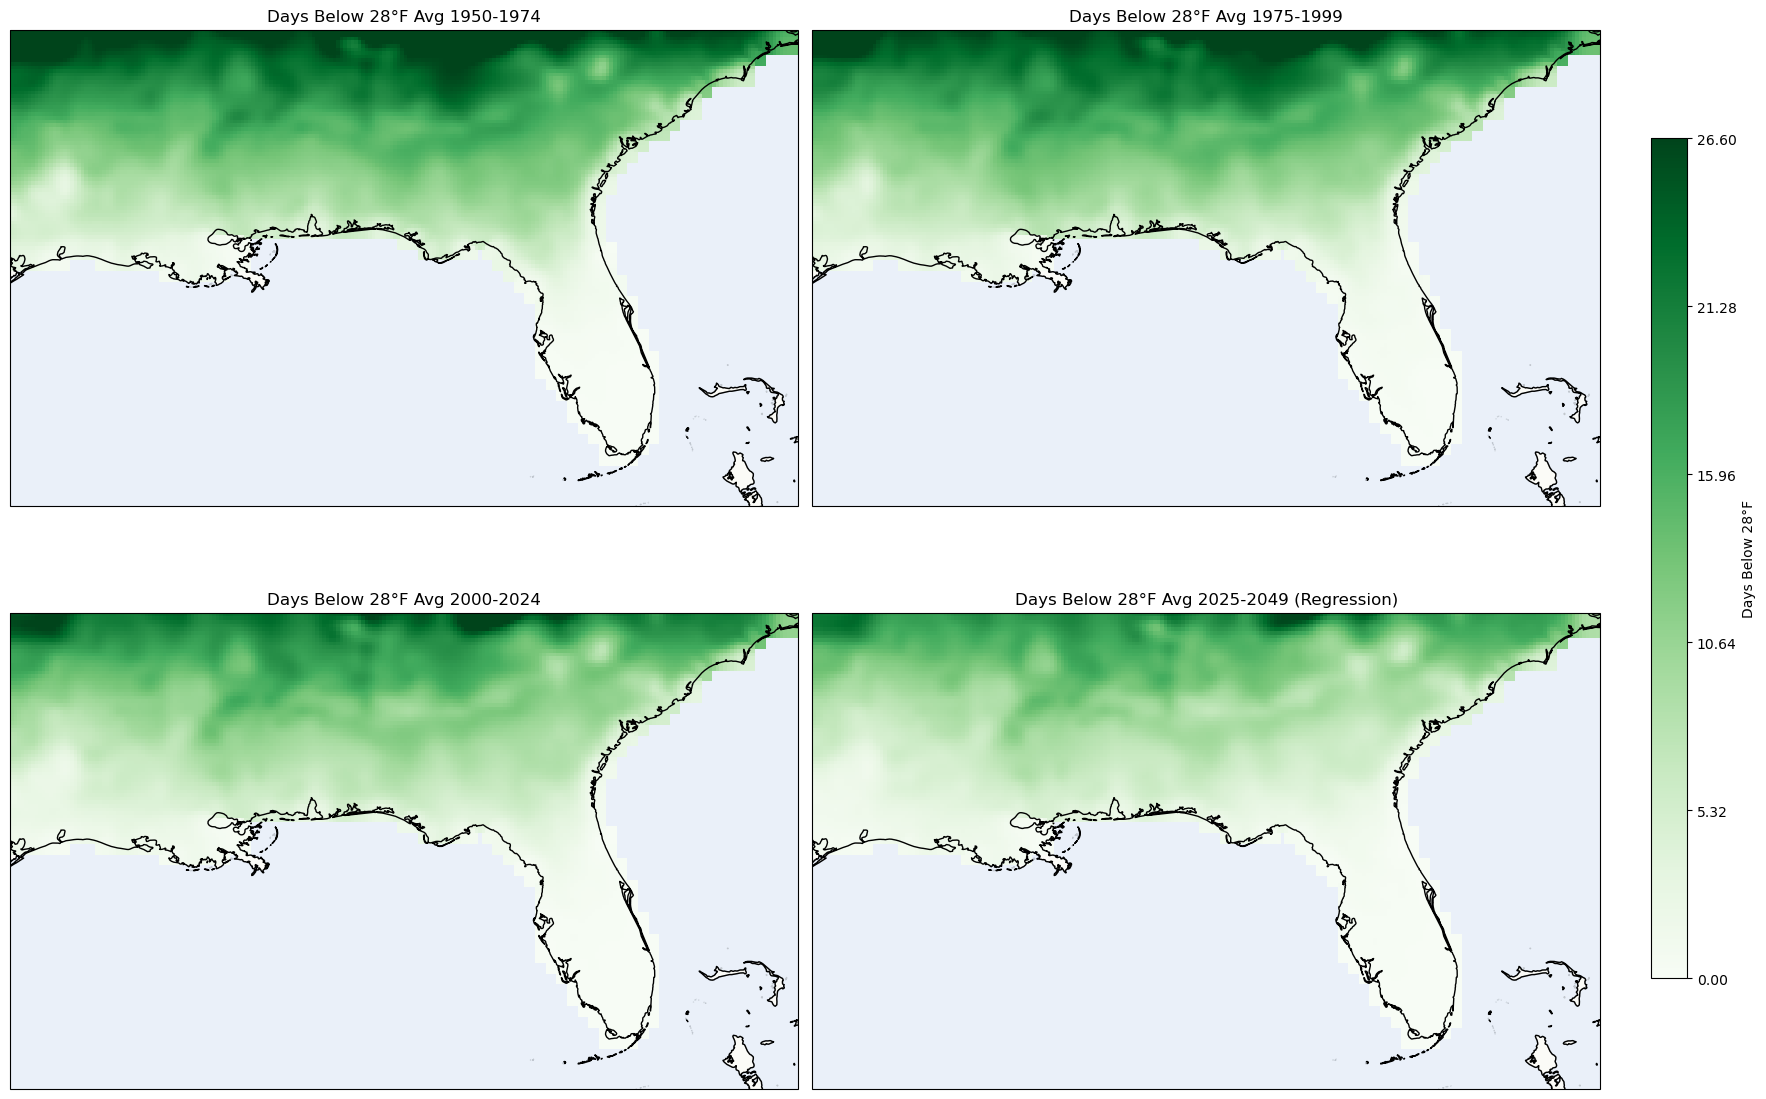

In [8]:
# --- Define time periods ---
time_periods = {
    "1950-1974": (1950, 1974),
    "1975-1999": (1975, 1999),
    "2000-2024": (2000, 2024),
    "2025-2049 (Regression)": (2025, 2049)   # <-- regression forecast
}

UPSAMPLE = 3
GAUSS_SIGMA = 1

# --- Precompute global min/max across historical periods only ---
all_values = []
for (start, end) in time_periods.values():
    if end <= 2024:  # only use actual data for min/max
        df_avg = (
            df[(df['Year'] >= start) & (df['Year'] <= end)]
            .groupby(['Lat','Lon'])['days_below_28F']
            .mean()
            .unstack()
        )
        all_values.append(df_avg.values)

all_values = np.concatenate([arr.ravel() for arr in all_values])
global_vmin = 0
global_vmax = np.nanpercentile(all_values, 95)

# --- Shared normalization ---
norm = Normalize(vmin=global_vmin, vmax=global_vmax)

# --- Create 2x2 grid ---
fig, axes = plt.subplots(
    2, 2, figsize=(18, 12),
    subplot_kw={'projection': ccrs.PlateCarree()}
)
axes = axes.flatten()

# --- Loop through periods ---
for i, (label, (start, end)) in enumerate(time_periods.items()):
    if end <= 2024:
        # Historical averages
        df_avg = (
            df[(df['Year'] >= start) & (df['Year'] <= end)]
            .groupby(['Lat','Lon'])['days_below_28F']
            .mean()
            .unstack()
            .sort_index(axis=0)
            .sort_index(axis=1)
        )
    else:
        # Regression forecast for 2025–2049
        def forecast(g):
            X = g['Year'].values.reshape(-1, 1)          # NumPy array
            y = g['days_below_28F'].values
            model = LinearRegression().fit(X, y)
            future_years = np.arange(start, end+1).reshape(-1, 1)
            preds = model.predict(future_years)
            return preds.mean()
        
        df_avg = (
            df[df['Year'] <= 2024]
            .groupby(['Lat','Lon'])
            .apply(forecast)
            .unstack()
            .sort_index(axis=0)
            .sort_index(axis=1)
        )
    
    lat = df_avg.index.values
    lon = df_avg.columns.values
    data = df_avg.values
    
    # Interpolate to smooth grid
    interp = RegularGridInterpolator((lat, lon), data,
                                     bounds_error=False, fill_value=np.nan)
    lat_f = np.linspace(lat.min(), lat.max(), len(lat) * UPSAMPLE)
    lon_f = np.linspace(lon.min(), lon.max(), len(lon) * UPSAMPLE)
    Lon_f, Lat_f = np.meshgrid(lon_f, lat_f)
    pts = np.stack([Lat_f.ravel(), Lon_f.ravel()], axis=1)
    data_f = interp(pts).reshape(Lat_f.shape)
    
    # Gaussian smoothing
    mask = np.isnan(data_f)
    tmp = data_f.copy(); tmp[mask] = 0.0
    w = (~mask).astype(float)
    tmp_blur = gaussian_filter(tmp, sigma=GAUSS_SIGMA)
    w_blur = gaussian_filter(w, sigma=GAUSS_SIGMA)
    with np.errstate(invalid='ignore', divide='ignore'):
        data_f = tmp_blur / w_blur
    data_f[w_blur == 0] = np.nan
    
    # Plot
    ax = axes[i]
    cmap = 'Greens'
    mesh = ax.pcolormesh(Lon_f, Lat_f, data_f,
                         cmap=cmap, shading='auto',
                         transform=ccrs.PlateCarree(), norm=norm)
    ax.coastlines(); ax.add_feature(cfeature.BORDERS, linestyle=':')
    ax.add_feature(cfeature.LAND, edgecolor='black', alpha=0.2)
    ax.add_feature(cfeature.OCEAN, alpha=0.2)
    ax.set_title(f"Days Below 28°F Avg {label}", fontsize=12)

# --- Dedicated axis for shared colorbar ---
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
cbar = fig.colorbar(mesh, cax=cbar_ax)
cbar.set_label("Days Below 28°F")
cbar.set_ticks(np.linspace(global_vmin, global_vmax, 6))

# Adjust layout to leave space for colorbar
plt.tight_layout(rect=[0, 0, 0.9, 1])
plt.show()


### Plot Days Below 32 as an Indicator of Possible Climate Unsuitability

/var/folders/3p/cs07b9rs4vx__r1rpt2kvmn00000gn/T/ipykernel_65498/1982696400.py:63: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(forecast)
/var/folders/3p/cs07b9rs4vx__r1rpt2kvmn00000gn/T/ipykernel_65498/1982696400.py:110: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])


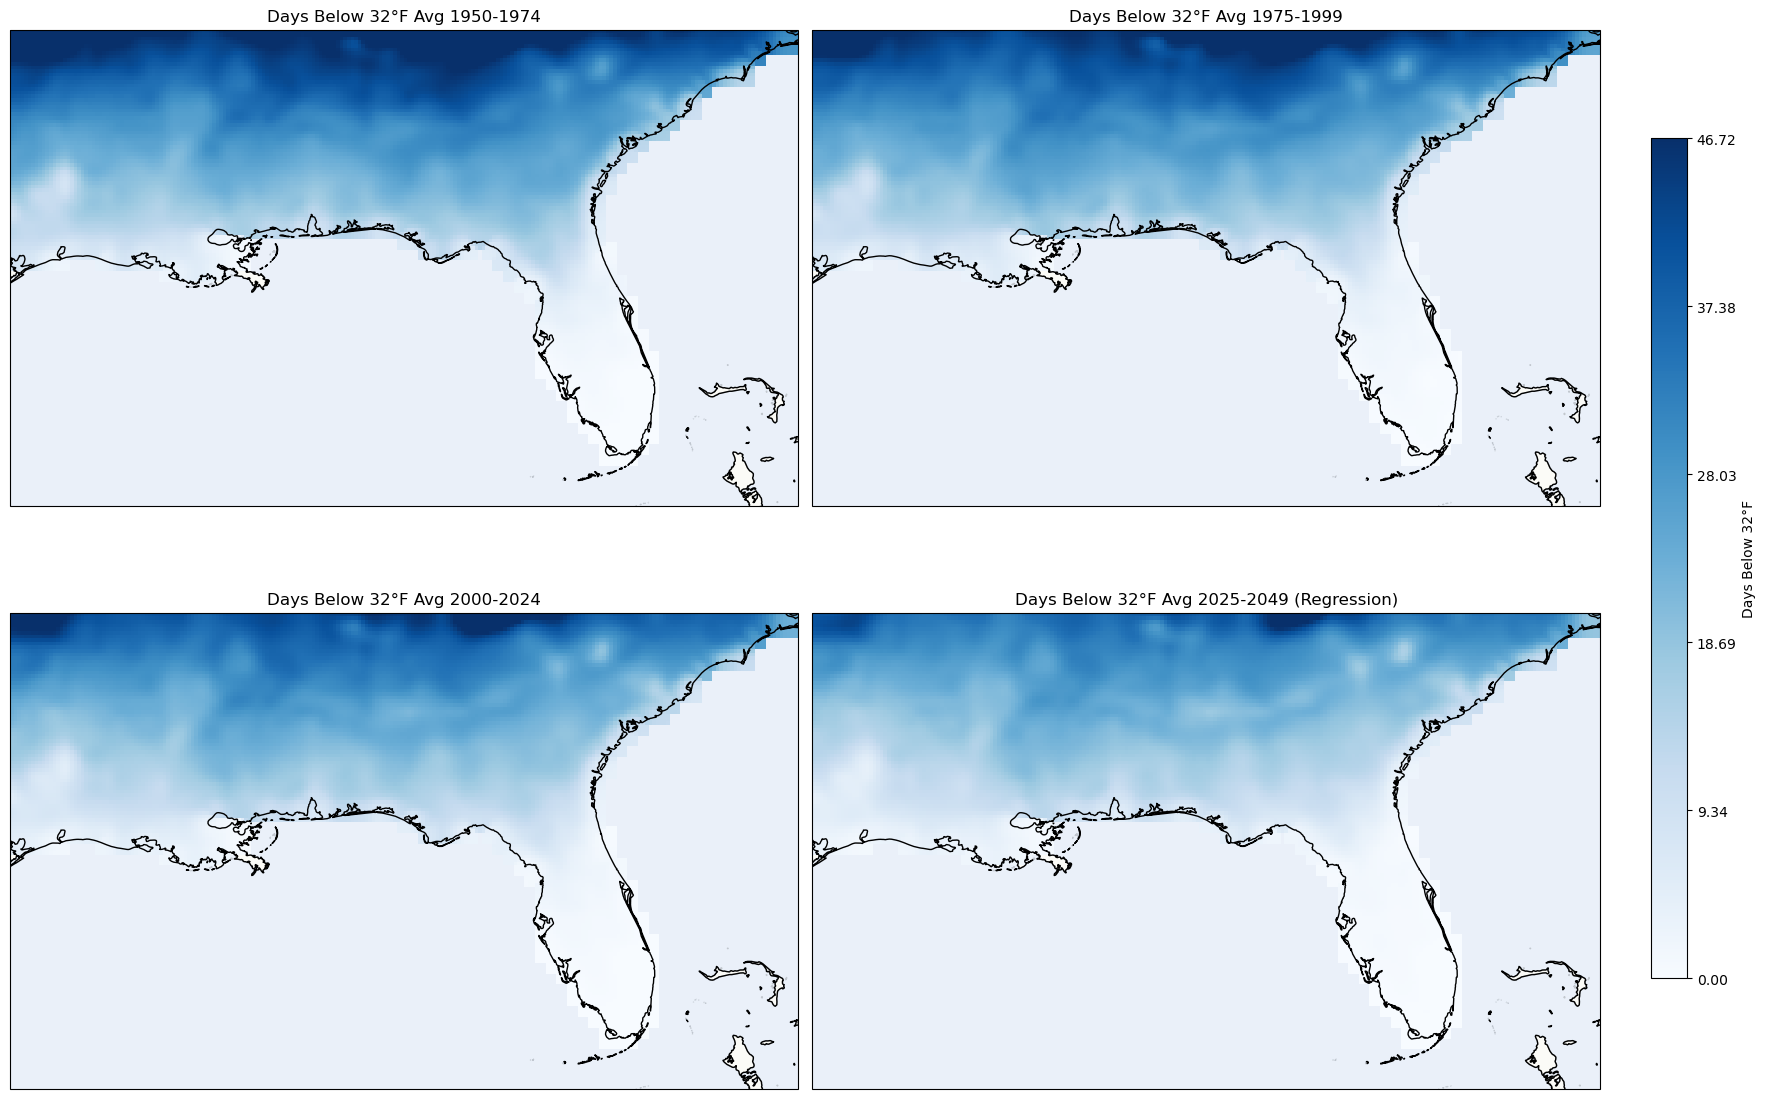

In [10]:
# --- Define time periods ---
time_periods = {
    "1950-1974": (1950, 1974),
    "1975-1999": (1975, 1999),
    "2000-2024": (2000, 2024),
    "2025-2049 (Regression)": (2025, 2049)   # regression forecast
}

UPSAMPLE = 3
GAUSS_SIGMA = 1

# --- Precompute global min/max across historical periods only ---
all_values = []
for (start, end) in time_periods.values():
    if end <= 2024:  # only use actual data for min/max
        df_avg = (
            df[(df['Year'] >= start) & (df['Year'] <= end)]
            .groupby(['Lat','Lon'])['days_below_32F']   # <-- swapped metric
            .mean()
            .unstack()
        )
        all_values.append(df_avg.values)

all_values = np.concatenate([arr.ravel() for arr in all_values])
global_vmin = 0
global_vmax = np.nanpercentile(all_values, 95)

# --- Shared normalization ---
norm = Normalize(vmin=global_vmin, vmax=global_vmax)

# --- Create 2x2 grid ---
fig, axes = plt.subplots(
    2, 2, figsize=(18, 12),
    subplot_kw={'projection': ccrs.PlateCarree()}
)
axes = axes.flatten()

# --- Loop through periods ---
for i, (label, (start, end)) in enumerate(time_periods.items()):
    if end <= 2024:
        # Historical averages
        df_avg = (
            df[(df['Year'] >= start) & (df['Year'] <= end)]
            .groupby(['Lat','Lon'])['days_below_32F']   # <-- swapped metric
            .mean()
            .unstack()
            .sort_index(axis=0)
            .sort_index(axis=1)
        )
    else:
        # Regression forecast for 2025–2049
        def forecast(g):
            X = g['Year'].values.reshape(-1, 1)          # NumPy array
            y = g['days_below_32F'].values               # <-- swapped metric
            model = LinearRegression().fit(X, y)
            future_years = np.arange(start, end+1).reshape(-1, 1)
            preds = model.predict(future_years)
            return preds.mean()
        
        df_avg = (
            df[df['Year'] <= 2024]
            .groupby(['Lat','Lon'])
            .apply(forecast)
            .unstack()
            .sort_index(axis=0)
            .sort_index(axis=1)
        )
    
    lat = df_avg.index.values
    lon = df_avg.columns.values
    data = df_avg.values
    
    # Interpolate to smooth grid
    interp = RegularGridInterpolator((lat, lon), data,
                                     bounds_error=False, fill_value=np.nan)
    lat_f = np.linspace(lat.min(), lat.max(), len(lat) * UPSAMPLE)
    lon_f = np.linspace(lon.min(), lon.max(), len(lon) * UPSAMPLE)
    Lon_f, Lat_f = np.meshgrid(lon_f, lat_f)
    pts = np.stack([Lat_f.ravel(), Lon_f.ravel()], axis=1)
    data_f = interp(pts).reshape(Lat_f.shape)
    
    # Gaussian smoothing
    mask = np.isnan(data_f)
    tmp = data_f.copy(); tmp[mask] = 0.0
    w = (~mask).astype(float)
    tmp_blur = gaussian_filter(tmp, sigma=GAUSS_SIGMA)
    w_blur = gaussian_filter(w, sigma=GAUSS_SIGMA)
    with np.errstate(invalid='ignore', divide='ignore'):
        data_f = tmp_blur / w_blur
    data_f[w_blur == 0] = np.nan
    
    # Plot
    ax = axes[i]
    cmap = 'Blues'
    mesh = ax.pcolormesh(Lon_f, Lat_f, data_f,
                         cmap=cmap, shading='auto',
                         transform=ccrs.PlateCarree(), norm=norm)
    ax.coastlines(); ax.add_feature(cfeature.BORDERS, linestyle=':')
    ax.add_feature(cfeature.LAND, edgecolor='black', alpha=0.2)
    ax.add_feature(cfeature.OCEAN, alpha=0.2)
    ax.set_title(f"Days Below 32°F Avg {label}", fontsize=12)

# --- Dedicated axis for shared colorbar ---
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
cbar = fig.colorbar(mesh, cax=cbar_ax)
cbar.set_label("Days Below 32°F")
cbar.set_ticks(np.linspace(global_vmin, global_vmax, 6))

# Adjust layout to leave space for colorbar
plt.tight_layout(rect=[0, 0, 0.9, 1])
plt.show()


### Plot Days Below 28 as an Indicator of General Climate Unsuitability

/var/folders/3p/cs07b9rs4vx__r1rpt2kvmn00000gn/T/ipykernel_65498/1867538268.py:63: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(forecast)
/var/folders/3p/cs07b9rs4vx__r1rpt2kvmn00000gn/T/ipykernel_65498/1867538268.py:110: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])


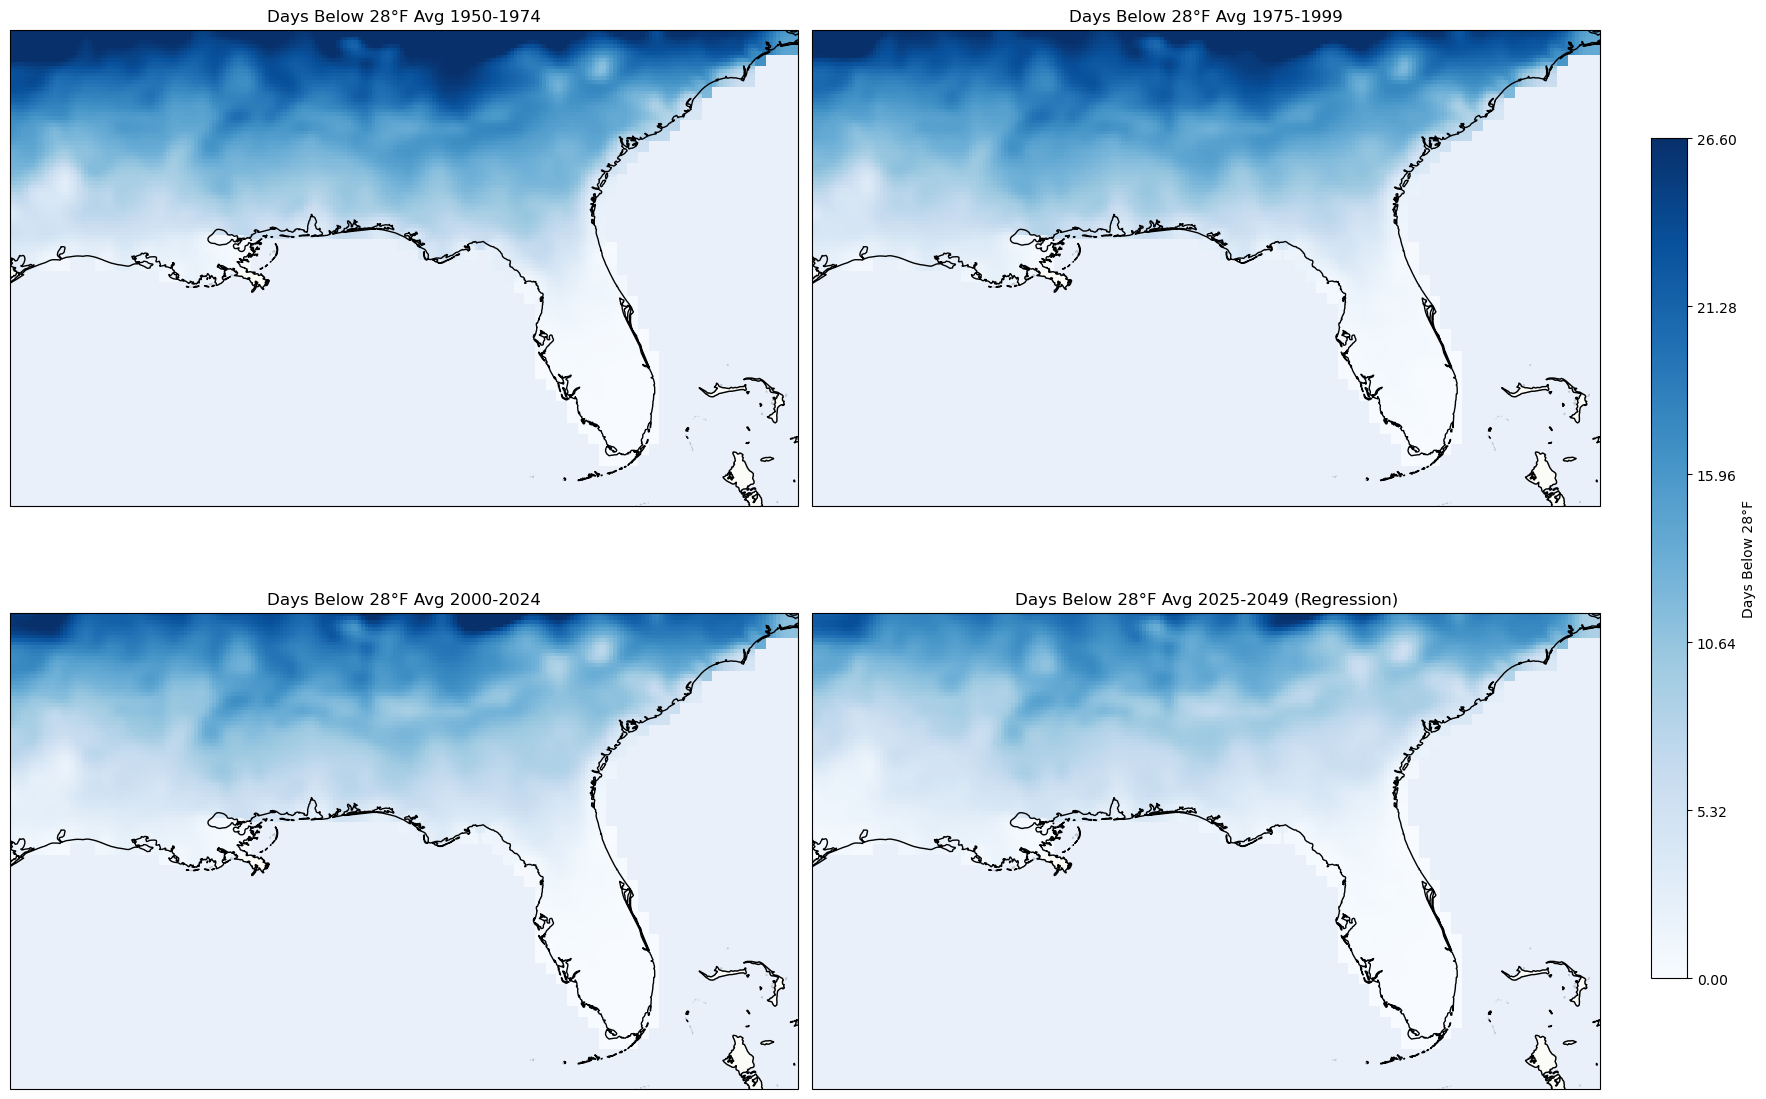

In [12]:
# --- Define time periods ---
time_periods = {
    "1950-1974": (1950, 1974),
    "1975-1999": (1975, 1999),
    "2000-2024": (2000, 2024),
    "2025-2049 (Regression)": (2025, 2049)   # regression forecast
}

UPSAMPLE = 3
GAUSS_SIGMA = 1

# --- Precompute global min/max across historical periods only ---
all_values = []
for (start, end) in time_periods.values():
    if end <= 2024:  # only use actual data for min/max
        df_avg = (
            df[(df['Year'] >= start) & (df['Year'] <= end)]
            .groupby(['Lat','Lon'])['days_below_28F']   # <-- swapped metric
            .mean()
            .unstack()
        )
        all_values.append(df_avg.values)

all_values = np.concatenate([arr.ravel() for arr in all_values])
global_vmin = 0
global_vmax = np.nanpercentile(all_values, 95)

# --- Shared normalization ---
norm = Normalize(vmin=global_vmin, vmax=global_vmax)

# --- Create 2x2 grid ---
fig, axes = plt.subplots(
    2, 2, figsize=(18, 12),
    subplot_kw={'projection': ccrs.PlateCarree()}
)
axes = axes.flatten()

# --- Loop through periods ---
for i, (label, (start, end)) in enumerate(time_periods.items()):
    if end <= 2024:
        # Historical averages
        df_avg = (
            df[(df['Year'] >= start) & (df['Year'] <= end)]
            .groupby(['Lat','Lon'])['days_below_28F']   # <-- swapped metric
            .mean()
            .unstack()
            .sort_index(axis=0)
            .sort_index(axis=1)
        )
    else:
        # Regression forecast for 2025–2049
        def forecast(g):
            X = g['Year'].values.reshape(-1, 1)          # NumPy array
            y = g['days_below_28F'].values               # <-- swapped metric
            model = LinearRegression().fit(X, y)
            future_years = np.arange(start, end+1).reshape(-1, 1)
            preds = model.predict(future_years)
            return preds.mean()
        
        df_avg = (
            df[df['Year'] <= 2024]
            .groupby(['Lat','Lon'])
            .apply(forecast)
            .unstack()
            .sort_index(axis=0)
            .sort_index(axis=1)
        )
    
    lat = df_avg.index.values
    lon = df_avg.columns.values
    data = df_avg.values
    
    # Interpolate to smooth grid
    interp = RegularGridInterpolator((lat, lon), data,
                                     bounds_error=False, fill_value=np.nan)
    lat_f = np.linspace(lat.min(), lat.max(), len(lat) * UPSAMPLE)
    lon_f = np.linspace(lon.min(), lon.max(), len(lon) * UPSAMPLE)
    Lon_f, Lat_f = np.meshgrid(lon_f, lat_f)
    pts = np.stack([Lat_f.ravel(), Lon_f.ravel()], axis=1)
    data_f = interp(pts).reshape(Lat_f.shape)
    
    # Gaussian smoothing
    mask = np.isnan(data_f)
    tmp = data_f.copy(); tmp[mask] = 0.0
    w = (~mask).astype(float)
    tmp_blur = gaussian_filter(tmp, sigma=GAUSS_SIGMA)
    w_blur = gaussian_filter(w, sigma=GAUSS_SIGMA)
    with np.errstate(invalid='ignore', divide='ignore'):
        data_f = tmp_blur / w_blur
    data_f[w_blur == 0] = np.nan
    
    # Plot
    ax = axes[i]
    cmap = 'Blues'
    mesh = ax.pcolormesh(Lon_f, Lat_f, data_f,
                         cmap=cmap, shading='auto',
                         transform=ccrs.PlateCarree(), norm=norm)
    ax.coastlines(); ax.add_feature(cfeature.BORDERS, linestyle=':')
    ax.add_feature(cfeature.LAND, edgecolor='black', alpha=0.2)
    ax.add_feature(cfeature.OCEAN, alpha=0.2)
    ax.set_title(f"Days Below 28°F Avg {label}", fontsize=12)

# --- Dedicated axis for shared colorbar ---
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
cbar = fig.colorbar(mesh, cax=cbar_ax)
cbar.set_label("Days Below 28°F")
cbar.set_ticks(np.linspace(global_vmin, global_vmax, 6))

# Adjust layout to leave space for colorbar
plt.tight_layout(rect=[0, 0, 0.9, 1])
plt.show()


### Plot Days Below 26 as an Indicator of Absolute Climate Unsuitability

/var/folders/3p/cs07b9rs4vx__r1rpt2kvmn00000gn/T/ipykernel_65498/3069434462.py:63: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(forecast)
/var/folders/3p/cs07b9rs4vx__r1rpt2kvmn00000gn/T/ipykernel_65498/3069434462.py:110: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])


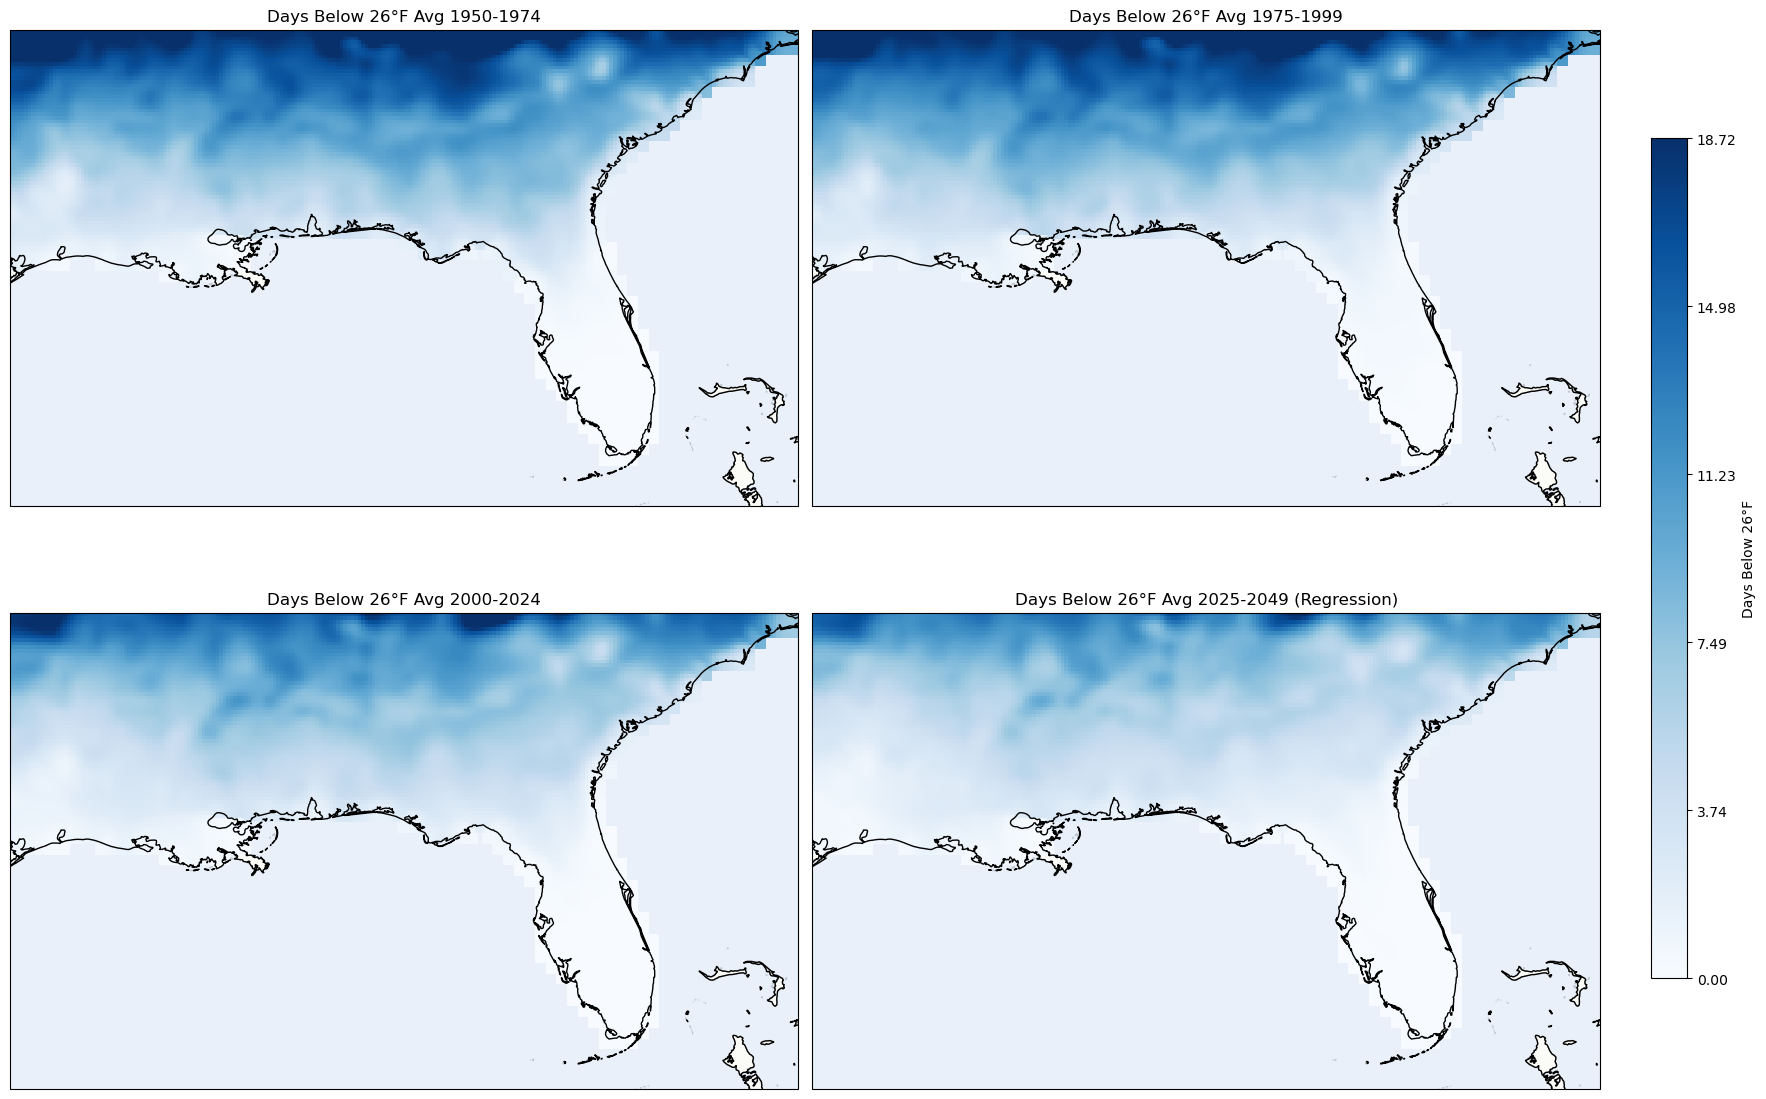

In [14]:
# --- Define time periods ---
time_periods = {
    "1950-1974": (1950, 1974),
    "1975-1999": (1975, 1999),
    "2000-2024": (2000, 2024),
    "2025-2049 (Regression)": (2025, 2049)   # regression forecast
}

UPSAMPLE = 3
GAUSS_SIGMA = 1

# --- Precompute global min/max across historical periods only ---
all_values = []
for (start, end) in time_periods.values():
    if end <= 2024:  # only use actual data for min/max
        df_avg = (
            df[(df['Year'] >= start) & (df['Year'] <= end)]
            .groupby(['Lat','Lon'])['days_below_26F']   # <-- swapped metric
            .mean()
            .unstack()
        )
        all_values.append(df_avg.values)

all_values = np.concatenate([arr.ravel() for arr in all_values])
global_vmin = 0
global_vmax = np.nanpercentile(all_values, 95)

# --- Shared normalization ---
norm = Normalize(vmin=global_vmin, vmax=global_vmax)

# --- Create 2x2 grid ---
fig, axes = plt.subplots(
    2, 2, figsize=(18, 12),
    subplot_kw={'projection': ccrs.PlateCarree()}
)
axes = axes.flatten()

# --- Loop through periods ---
for i, (label, (start, end)) in enumerate(time_periods.items()):
    if end <= 2024:
        # Historical averages
        df_avg = (
            df[(df['Year'] >= start) & (df['Year'] <= end)]
            .groupby(['Lat','Lon'])['days_below_26F']   # <-- swapped metric
            .mean()
            .unstack()
            .sort_index(axis=0)
            .sort_index(axis=1)
        )
    else:
        # Regression forecast for 2025–2049
        def forecast(g):
            X = g['Year'].values.reshape(-1, 1)          # NumPy array
            y = g['days_below_26F'].values               # <-- swapped metric
            model = LinearRegression().fit(X, y)
            future_years = np.arange(start, end+1).reshape(-1, 1)
            preds = model.predict(future_years)
            return preds.mean()
        
        df_avg = (
            df[df['Year'] <= 2024]
            .groupby(['Lat','Lon'])
            .apply(forecast)
            .unstack()
            .sort_index(axis=0)
            .sort_index(axis=1)
        )
    
    lat = df_avg.index.values
    lon = df_avg.columns.values
    data = df_avg.values
    
    # Interpolate to smooth grid
    interp = RegularGridInterpolator((lat, lon), data,
                                     bounds_error=False, fill_value=np.nan)
    lat_f = np.linspace(lat.min(), lat.max(), len(lat) * UPSAMPLE)
    lon_f = np.linspace(lon.min(), lon.max(), len(lon) * UPSAMPLE)
    Lon_f, Lat_f = np.meshgrid(lon_f, lat_f)
    pts = np.stack([Lat_f.ravel(), Lon_f.ravel()], axis=1)
    data_f = interp(pts).reshape(Lat_f.shape)
    
    # Gaussian smoothing
    mask = np.isnan(data_f)
    tmp = data_f.copy(); tmp[mask] = 0.0
    w = (~mask).astype(float)
    tmp_blur = gaussian_filter(tmp, sigma=GAUSS_SIGMA)
    w_blur = gaussian_filter(w, sigma=GAUSS_SIGMA)
    with np.errstate(invalid='ignore', divide='ignore'):
        data_f = tmp_blur / w_blur
    data_f[w_blur == 0] = np.nan
    
    # Plot
    ax = axes[i]
    cmap = 'Blues'
    mesh = ax.pcolormesh(Lon_f, Lat_f, data_f,
                         cmap=cmap, shading='auto',
                         transform=ccrs.PlateCarree(), norm=norm)
    ax.coastlines(); ax.add_feature(cfeature.BORDERS, linestyle=':')
    ax.add_feature(cfeature.LAND, edgecolor='black', alpha=0.2)
    ax.add_feature(cfeature.OCEAN, alpha=0.2)
    ax.set_title(f"Days Below 26°F Avg {label}", fontsize=12)

# --- Dedicated axis for shared colorbar ---
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
cbar = fig.colorbar(mesh, cax=cbar_ax)
cbar.set_label("Days Below 26°F")
cbar.set_ticks(np.linspace(global_vmin, global_vmax, 6))

# Adjust layout to leave space for colorbar
plt.tight_layout(rect=[0, 0, 0.9, 1])
plt.show()


### Plot annual minimum temperature by time period

/var/folders/3p/cs07b9rs4vx__r1rpt2kvmn00000gn/T/ipykernel_65498/3154987337.py:64: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(forecast)
/var/folders/3p/cs07b9rs4vx__r1rpt2kvmn00000gn/T/ipykernel_65498/3154987337.py:110: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])


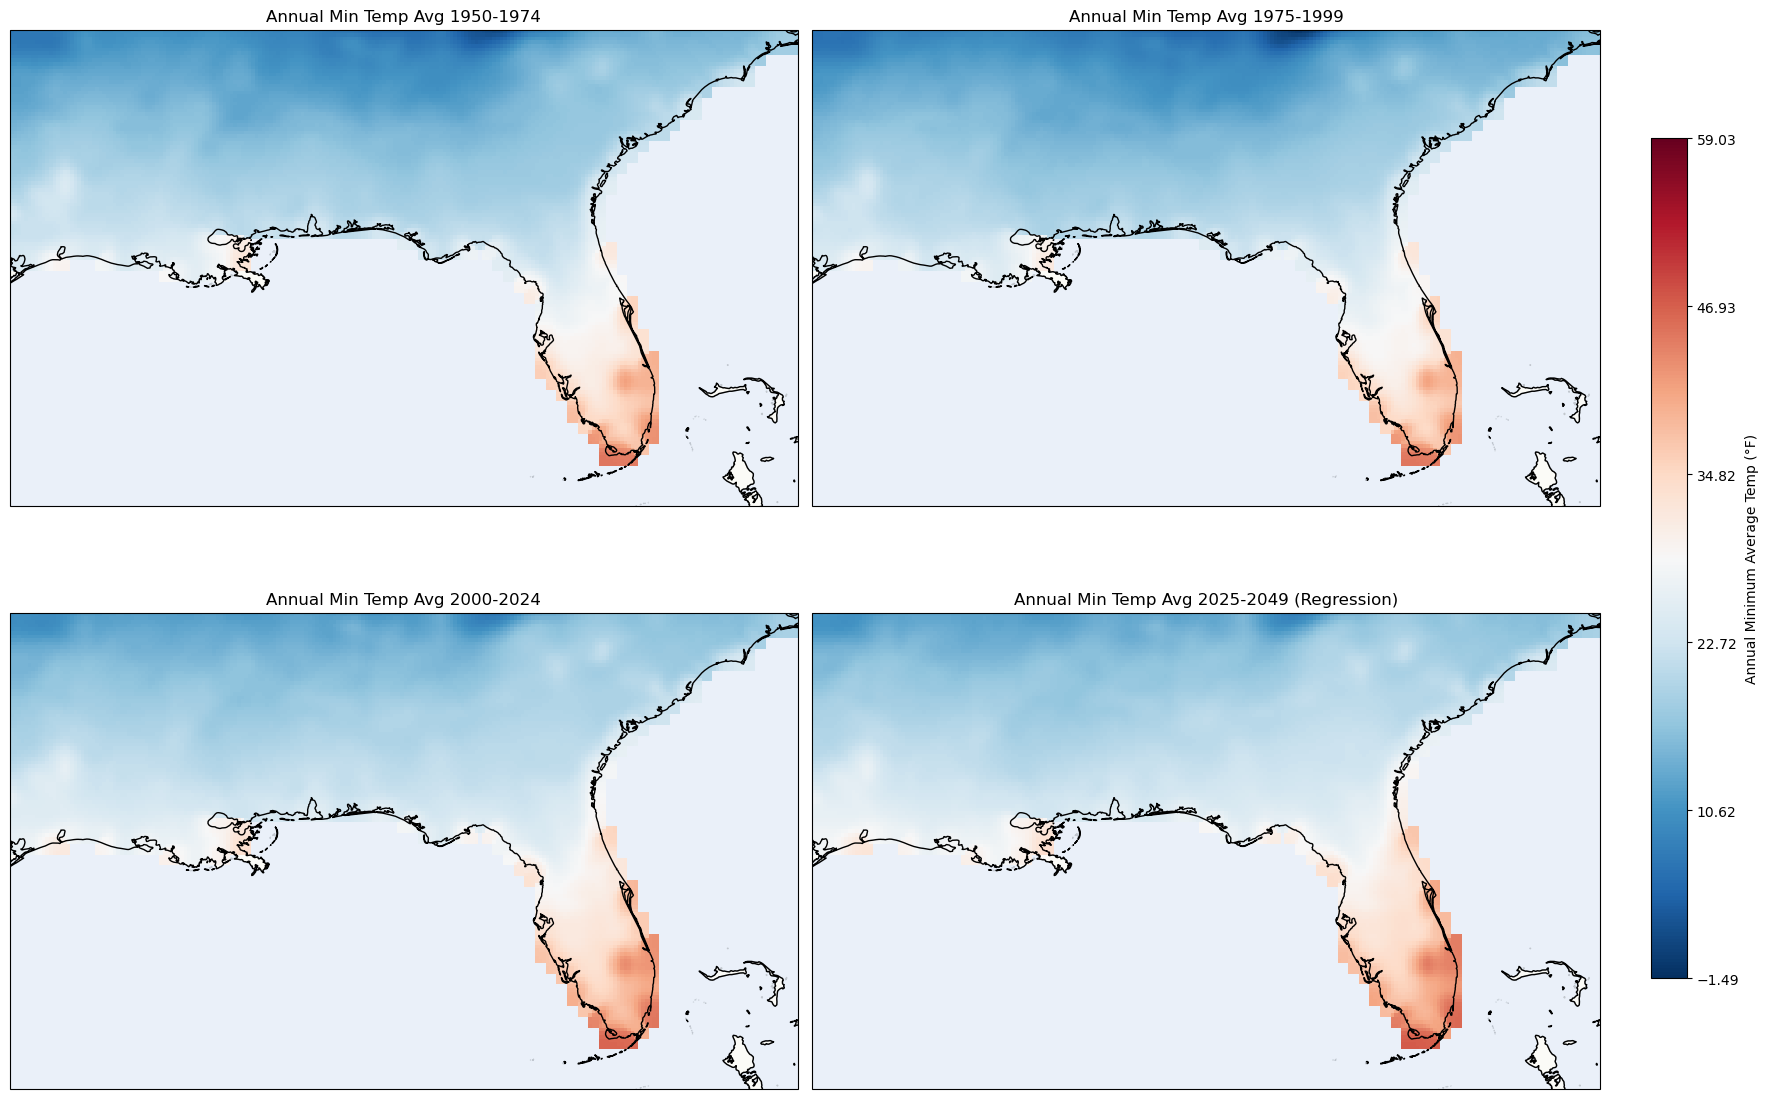

In [16]:
# --- Define time periods ---
time_periods = {
    "1950-1974": (1950, 1974),
    "1975-1999": (1975, 1999),
    "2000-2024": (2000, 2024),
    "2025-2049 (Regression)": (2025, 2049)   # regression forecast
}

UPSAMPLE = 3
GAUSS_SIGMA = 1
metric = 'annual_min_temp_F'

# --- Precompute global min/max across historical periods only ---
all_values = []
for (start, end) in time_periods.values():
    if end <= 2024:  # only use actual data for min/max
        df_avg = (
            df[(df['Year'] >= start) & (df['Year'] <= end)]
            .groupby(['Lat','Lon'])[metric]
            .mean()
            .unstack()
        )
        all_values.append(df_avg.values)

all_values = np.concatenate([arr.ravel() for arr in all_values])
global_vmin = np.nanmin(all_values)
global_vmax = np.nanmax(all_values)

# --- Shared normalization ---
norm = Normalize(vmin=global_vmin, vmax=global_vmax)

# --- Create 2x2 grid ---
fig, axes = plt.subplots(
    2, 2, figsize=(18, 12),
    subplot_kw={'projection': ccrs.PlateCarree()}
)
axes = axes.flatten()

# --- Loop through periods ---
for i, (label, (start, end)) in enumerate(time_periods.items()):
    if end <= 2024:
        # Historical averages
        df_avg = (
            df[(df['Year'] >= start) & (df['Year'] <= end)]
            .groupby(['Lat','Lon'])[metric]
            .mean()
            .unstack()
            .sort_index(axis=0)
            .sort_index(axis=1)
        )
    else:
        # Regression forecast for 2025–2049
        def forecast(g):
            X = g['Year'].values.reshape(-1, 1)
            y = g[metric].values
            model = LinearRegression().fit(X, y)
            future_years = np.arange(start, end+1).reshape(-1, 1)
            preds = model.predict(future_years)
            return preds.mean()
        
        df_avg = (
            df[df['Year'] <= 2024]
            .groupby(['Lat','Lon'])
            .apply(forecast)
            .unstack()
            .sort_index(axis=0)
            .sort_index(axis=1)
        )
    
    lat = df_avg.index.values
    lon = df_avg.columns.values
    data = df_avg.values
    
    # Interpolate to smooth grid
    interp = RegularGridInterpolator((lat, lon), data,
                                     bounds_error=False, fill_value=np.nan)
    lat_f = np.linspace(lat.min(), lat.max(), len(lat) * UPSAMPLE)
    lon_f = np.linspace(lon.min(), lon.max(), len(lon) * UPSAMPLE)
    Lon_f, Lat_f = np.meshgrid(lon_f, lat_f)
    pts = np.stack([Lat_f.ravel(), Lon_f.ravel()], axis=1)
    data_f = interp(pts).reshape(Lat_f.shape)
    
    # Gaussian smoothing
    mask = np.isnan(data_f)
    tmp = data_f.copy(); tmp[mask] = 0.0
    w = (~mask).astype(float)
    tmp_blur = gaussian_filter(tmp, sigma=GAUSS_SIGMA)
    w_blur = gaussian_filter(w, sigma=GAUSS_SIGMA)
    with np.errstate(invalid='ignore', divide='ignore'):
        data_f = tmp_blur / w_blur
    data_f[w_blur == 0] = np.nan
    
    # Plot
    ax = axes[i]
    cmap = 'RdBu_r'
    mesh = ax.pcolormesh(Lon_f, Lat_f, data_f,
                         cmap=cmap, shading='auto',
                         transform=ccrs.PlateCarree(), norm=norm)
    ax.coastlines(); ax.add_feature(cfeature.BORDERS, linestyle=':')
    ax.add_feature(cfeature.LAND, edgecolor='black', alpha=0.2)
    ax.add_feature(cfeature.OCEAN, alpha=0.2)
    ax.set_title(f"Annual Min Temp Avg {label}", fontsize=12)

# --- Dedicated axis for shared colorbar ---
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
cbar = fig.colorbar(mesh, cax=cbar_ax)
cbar.set_label("Annual Minimum Average Temp (°F)")
cbar.set_ticks(np.linspace(global_vmin, global_vmax, 6))

plt.tight_layout(rect=[0, 0, 0.9, 1])
plt.show()


### Assign Climate Scores by Time Slices After a High Level Review of Citrus Growing Zone Requirements

In [18]:
# -----------------------------
# Step 1: Load your dataset
# -----------------------------
# df = pd.read_csv("your_file.csv")  
# Columns expected: ['Year','Lat','Lon','days_below_55F','days_below_32F',
#                    'days_below_28F','days_below_26F','annual_min_temp_F']

# -----------------------------
# Step 2: Define metrics, future years, and time periods
# -----------------------------
metrics = ['days_below_55F','days_below_32F','days_below_28F',
           'days_below_26F','annual_min_temp_F']
future_years = np.arange(2026, 2051).reshape(-1,1)

time_periods = {
    "1950-1974": (1950, 1974),
    "1975-1999": (1975, 1999),
    "2000-2024": (2000, 2024),
    "2025-2049": (2025, 2049)
}

# -----------------------------
# Step 3: Loop through metrics
# -----------------------------
all_scores = {period: {} for period in time_periods}  # store per-metric and totals

for metric in metrics:
    # Compute mean per year across all locations
    yearly_mean = df.groupby('Year')[metric].mean().reset_index()
    
    # Exclude 2025 since it's incomplete
    yearly_mean = yearly_mean[yearly_mean['Year'] < 2025]
    
    X = yearly_mean[['Year']].values
    y = yearly_mean[metric].values
    
    # Fit regression
    model = LinearRegression()
    model.fit(X, y)
    
    # Predict future years (2026–2050)
    y_future = model.predict(future_years)
    
    # -----------------------------
    # Step 4: Calculate climate scores by time periods
    # -----------------------------
    print(f"\nClimate scores for {metric}:")
    for label, (start, end) in time_periods.items():
        mask = (df['Year'] >= start) & (df['Year'] <= end)
        score = df.loc[mask, metric].mean()
        all_scores[label][metric] = score
        print(f"  {label}: {score:.2f}")

# -----------------------------
# Step 5: Compute total climate score per time period
# -----------------------------
print("\n=== Total Climate Scores by Time Period ===")
for label in time_periods:
    # Example: sum across metrics (could also use mean if preferred)
    total_score = sum(all_scores[label].values())
    print(f"  {label}: {total_score:.2f}")



Climate scores for days_below_55F:
  1950-1974: 150.63
  1975-1999: 151.15
  2000-2024: 141.06
  2025-2049: 91.30

Climate scores for days_below_32F:
  1950-1974: 26.74
  1975-1999: 25.52
  2000-2024: 21.71
  2025-2049: 18.27

Climate scores for days_below_28F:
  1950-1974: 14.06
  1975-1999: 13.50
  2000-2024: 10.53
  2025-2049: 10.72

Climate scores for days_below_26F:
  1950-1974: 9.43
  1975-1999: 9.25
  2000-2024: 6.64
  2025-2049: 7.83

Climate scores for annual_min_temp_F:
  1950-1974: 17.94
  1975-1999: 17.50
  2000-2024: 20.64
  2025-2049: 17.79

=== Total Climate Scores by Time Period ===
  1950-1974: 218.80
  1975-1999: 216.92
  2000-2024: 200.59
  2025-2049: 145.91


### Sum and Plot Climate Scores by Region

/var/folders/3p/cs07b9rs4vx__r1rpt2kvmn00000gn/T/ipykernel_65498/268512411.py:58: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.nlargest(5, 'climate_score'))
/var/folders/3p/cs07b9rs4vx__r1rpt2kvmn00000gn/T/ipykernel_65498/268512411.py:64: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.loc[g['climate_score'].idxmax()])


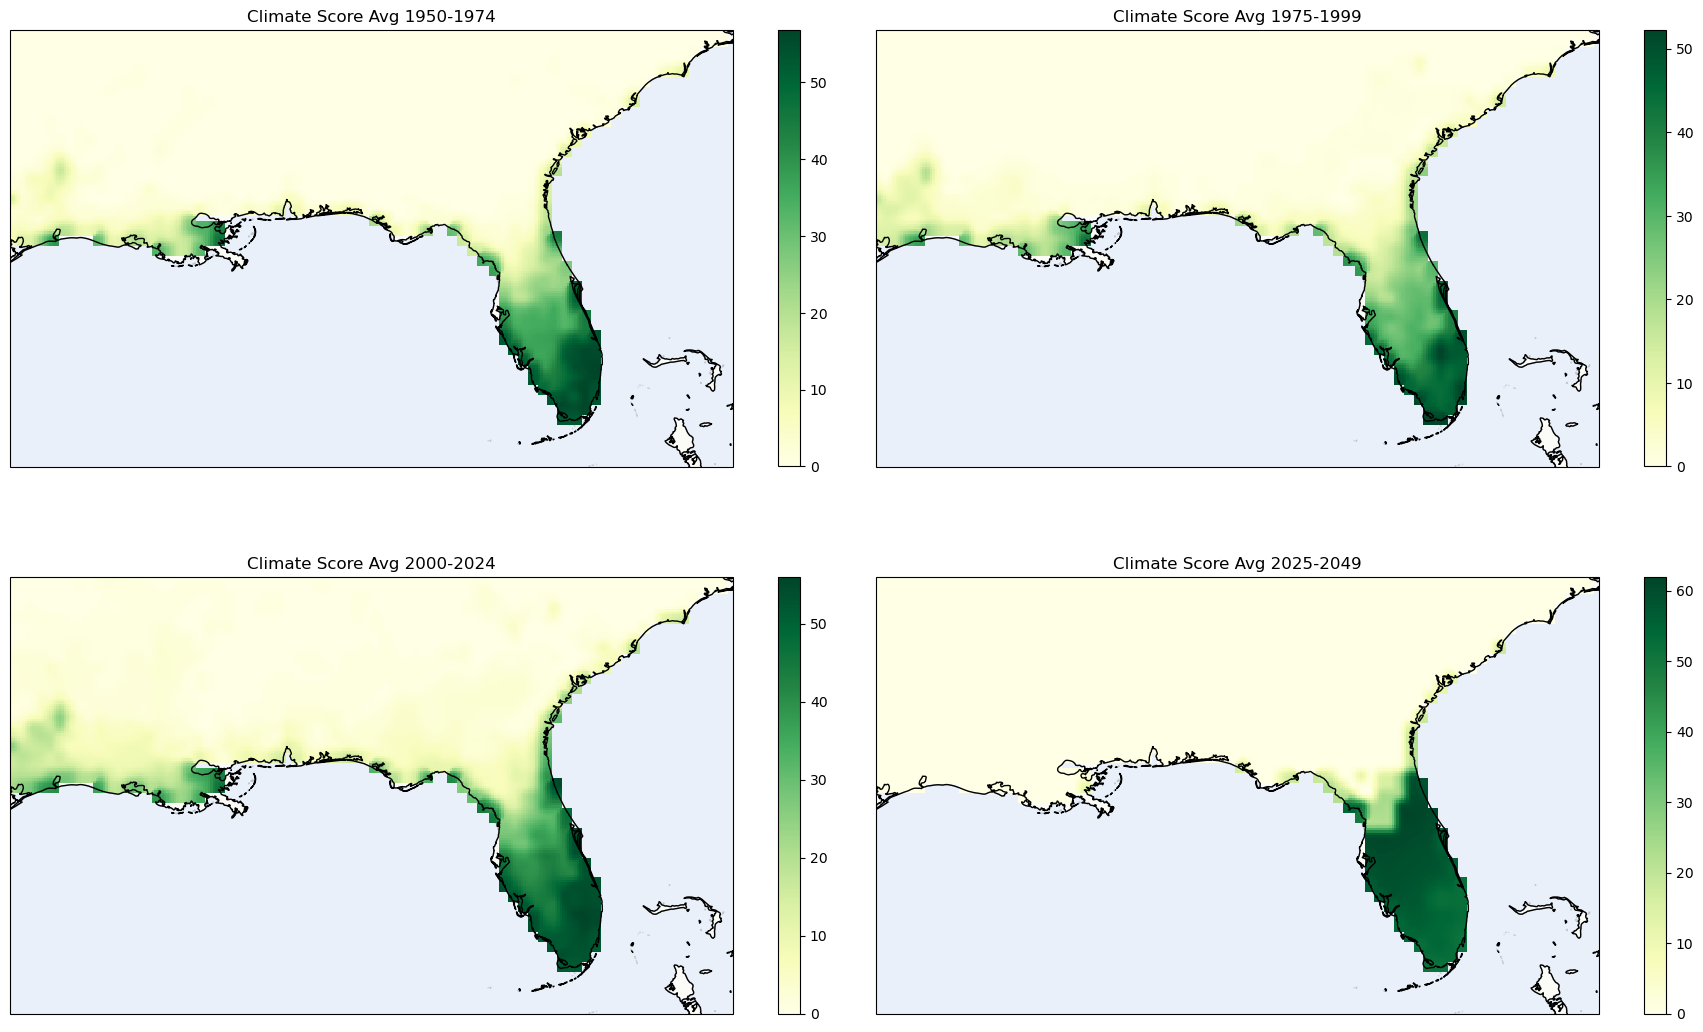

In [20]:
# --- Define climate_score ---
df['climate_score'] = (
    df['annual_min_temp_F']
    - 0.5*df['days_below_55F']
    - 1.0*df['days_below_32F']
    - 2.0*df['days_below_26F']
)

# --- Region classification ---
def classify_region(lat):
    if lat < 27:
        return "South FL"
    elif 27 <= lat < 29.5:
        return "Central FL"
    elif 29.5 <= lat <= 31:
        return "North FL & Equiv Lats"
    else:
        return "North of FL"

df['Region'] = df['Lat'].apply(classify_region)
region_order = ["South FL", "Central FL", "North FL & Equiv Lats", "North of FL"]

# --- Period classification ---
def classify_period(year):
    if 1950 <= year <= 1974:
        return "1950-1974"
    elif 1975 <= year <= 1999:
        return "1975-1999"
    elif 2000 <= year <= 2024:
        return "2000-2024"
    elif 2025 <= year <= 2049:
        return "2025-2049"
    else:
        return "Other"

df['Period'] = df['Year'].apply(classify_period)
period_order = ["1950-1974", "1975-1999", "2000-2024", "2025-2049"]

# --- Climate score summary by Region + Period ---
result = (
    df.groupby(['Region','Period'])
      .agg(
          Percent_above_0 = ('climate_score', lambda x: (x > 0).mean() * 100),
          Percent_above_25 = ('climate_score', lambda x: (x > 25).mean() * 100),
          Percent_above_50 = ('climate_score', lambda x: (x > 50).mean() * 100),
          Max_score = ('climate_score', 'max')
      )
      .reset_index()
)

result['Region'] = pd.Categorical(result['Region'], categories=region_order, ordered=True)
result['Period'] = pd.Categorical(result['Period'], categories=period_order, ordered=True)
result = result.sort_values(['Region','Period'])

# --- Top points per region + period ---
top_points = (
    df.groupby(['Region','Period'], group_keys=False)
      .apply(lambda g: g.nlargest(5, 'climate_score'))
)

# --- Max point per region + period ---
max_points = (
    df.groupby(['Region','Period'], group_keys=False)
      .apply(lambda g: g.loc[g['climate_score'].idxmax()])
)


# --- Climate scoring function ---
def citrus_climate_score(row):
    if row['days_below_26F'] > 0 or row['annual_min_temp_F'] < 26:
        return 0
    score = 0
    if row['days_below_32F'] == 0:
        score += 30
    elif row['days_below_32F'] <= 5:
        score += 10
    score += min(row['days_below_55F'] / 5, 40)
    if row['days_below_32F'] == 0 and row['days_below_28F'] == 0:
        score += 20
    return min(score, 100)

# --- Region classification ---
def classify_region(lat):
    if lat < 27: return "South FL"
    elif 27 <= lat < 29.5: return "Central FL"
    elif 29.5 <= lat <= 31: return "North FL & Equiv Lats"
    else: return "North of FL"

# --- Define time periods ---
time_periods = {
    "1950-1974": (1950, 1974),
    "1975-1999": (1975, 1999),
    "2000-2024": (2000, 2024),
    "2025-2049": (2025, 2049)
}

UPSAMPLE = 4
GAUSS_SIGMA = 0.8

# --- Assume df exists ---
df['Region'] = df['Lat'].apply(classify_region)
df['climate_score'] = df.apply(citrus_climate_score, axis=1)

# --- Create 2x2 grid of maps ---
fig, axes = plt.subplots(2, 2, figsize=(18, 12),
                         subplot_kw={'projection': ccrs.PlateCarree()})
axes = axes.flatten()

for i, (label, (start, end)) in enumerate(time_periods.items()):
    mask = (df['Year'] >= start) & (df['Year'] <= end)
    df_period = df.loc[mask]

    # Average climate score by location
    df_avg = df_period.groupby(['Lat','Lon'], as_index=False)['climate_score'].mean()
    pivot = df_avg.pivot(index='Lat', columns='Lon', values='climate_score').sort_index()

    lat, lon, data = pivot.index.values, pivot.columns.values, pivot.values

    # Interpolate + smooth
    interp = RegularGridInterpolator((lat, lon), data, bounds_error=False, fill_value=np.nan)
    lat_f = np.linspace(lat.min(), lat.max(), len(lat)*UPSAMPLE)
    lon_f = np.linspace(lon.min(), lon.max(), len(lon)*UPSAMPLE)
    Lon_f, Lat_f = np.meshgrid(lon_f, lat_f)
    pts = np.stack([Lat_f.ravel(), Lon_f.ravel()], axis=1)
    data_f = interp(pts).reshape(Lat_f.shape)

    if GAUSS_SIGMA > 0:
        mask_nan = np.isnan(data_f)
        tmp = data_f.copy(); tmp[mask_nan] = 0.0
        w = (~mask_nan).astype(float)
        tmp_blur = gaussian_filter(tmp, sigma=GAUSS_SIGMA)
        w_blur = gaussian_filter(w, sigma=GAUSS_SIGMA)
        data_f = np.divide(tmp_blur, w_blur, out=np.zeros_like(tmp_blur), where=w_blur!=0)
        data_f[w_blur==0] = np.nan

    # Plot map
    ax = axes[i]
    norm = Normalize(vmin=np.nanmin(data_f), vmax=np.nanmax(data_f))
    mesh = ax.pcolormesh(Lon_f, Lat_f, data_f,
                         cmap='YlGn', shading='auto',
                         transform=ccrs.PlateCarree(), norm=norm)
    ax.coastlines(); ax.add_feature(cfeature.BORDERS, linestyle=':')
    ax.add_feature(cfeature.LAND, edgecolor='black', alpha=0.2)
    ax.add_feature(cfeature.OCEAN, alpha=0.2)
    ax.set_title(f"Climate Score Avg {label}", fontsize=12)
    plt.colorbar(mesh, ax=ax, orientation='vertical', shrink=0.7)

plt.tight_layout()
plt.show()


### Show Top Five Scores by Region

/var/folders/3p/cs07b9rs4vx__r1rpt2kvmn00000gn/T/ipykernel_65498/2529468402.py:48: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top_points = df_period.groupby('Region', group_keys=False).apply(lambda g: g.nlargest(5, 'climate_score'))
/var/folders/3p/cs07b9rs4vx__r1rpt2kvmn00000gn/T/ipykernel_65498/2529468402.py:49: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  max_points = df_period.groupby('Region', grou

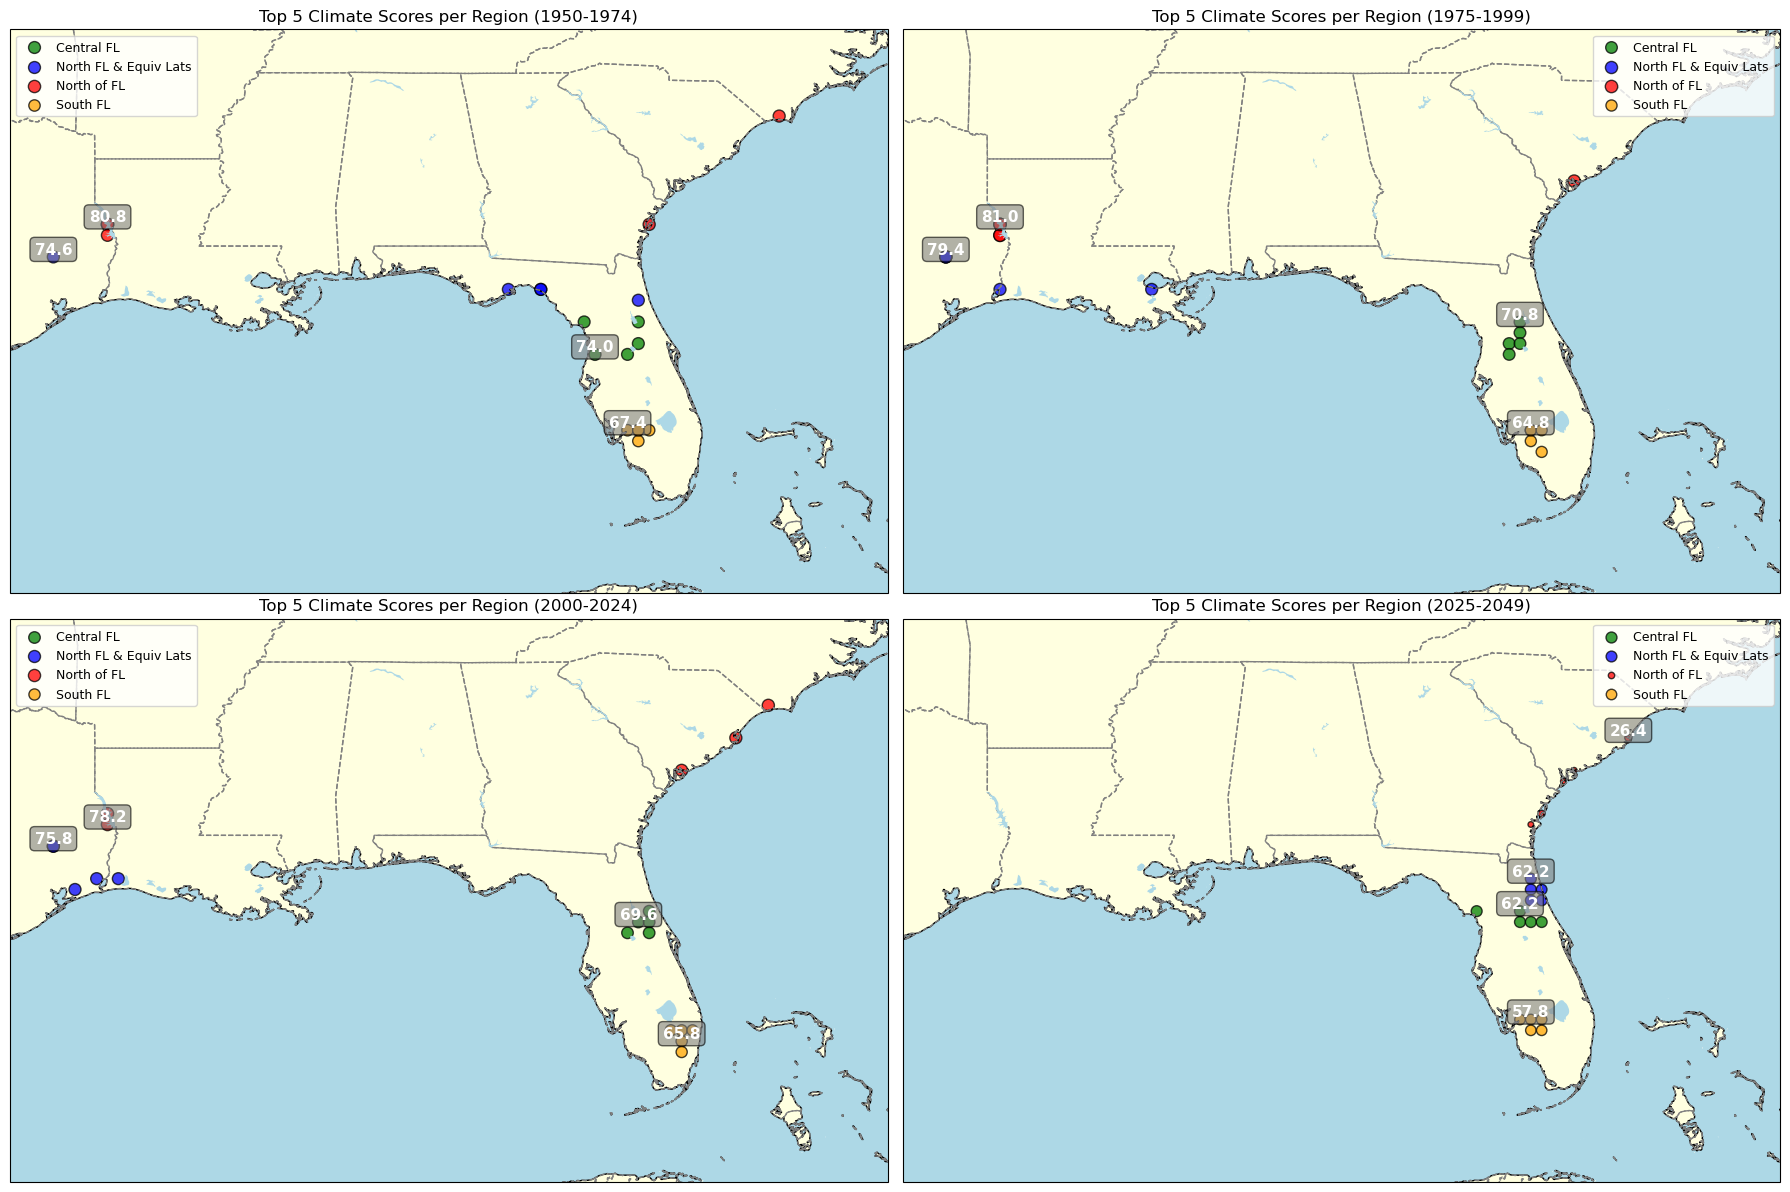

In [22]:
# --- Climate scoring function ---
def citrus_climate_score(row):
    if row['days_below_26F'] > 0 or row['annual_min_temp_F'] < 26:
        return 0
    score = 0
    if row['days_below_32F'] == 0:
        score += 30
    elif row['days_below_32F'] <= 5:
        score += 10
    score += min(row['days_below_55F'] / 5, 40)
    if row['days_below_32F'] == 0 and row['days_below_28F'] == 0:
        score += 20
    return min(score, 100)

# --- Region classification ---
def classify_region(lat):
    if lat < 27: return "South FL"
    elif 27 <= lat < 29.5: return "Central FL"
    elif 29.5 <= lat <= 31: return "North FL & Equiv Lats"
    else: return "North of FL"

region_order = ["South FL","Central FL","North FL & Equiv Lats","North of FL"]
colors = {"South FL":"orange","Central FL":"green","North FL & Equiv Lats":"blue","North of FL":"red"}

# --- Define time periods ---
time_periods = {
    "1950-1974": (1950, 1974),
    "1975-1999": (1975, 1999),
    "2000-2024": (2000, 2024),
    "2025-2049": (2025, 2049)
}

# --- Assume df exists ---
df['Region'] = df['Lat'].apply(classify_region)
df['climate_score'] = df.apply(citrus_climate_score, axis=1)

# --- Create 2x2 grid of scatter maps ---
fig, axes = plt.subplots(2, 2, figsize=(18, 12),
                         subplot_kw={'projection': ccrs.PlateCarree()})
axes = axes.flatten()

for i, (label, (start, end)) in enumerate(time_periods.items()):
    mask = (df['Year'] >= start) & (df['Year'] <= end)
    df_period = df.loc[mask].copy()
    df_period['climate_score'] = df_period.apply(citrus_climate_score, axis=1)

    # Top points per region
    top_points = df_period.groupby('Region', group_keys=False).apply(lambda g: g.nlargest(5, 'climate_score'))
    max_points = df_period.groupby('Region', group_keys=False).apply(lambda g: g.loc[g['climate_score'].idxmax()])

    ax = axes[i]
    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.BORDERS, linestyle=':')
    ax.add_feature(cfeature.STATES, linestyle='--', edgecolor='gray')
    ax.add_feature(cfeature.LAND, facecolor='lightyellow')
    ax.add_feature(cfeature.OCEAN, facecolor='lightblue')
    ax.add_feature(cfeature.LAKES, facecolor='lightblue')

    for region, group in top_points.groupby('Region'):
        ax.scatter(group['Lon'], group['Lat'],
                   s=np.clip(group['climate_score'], 10, 200),  # readable marker sizes
                   c=colors[region], label=region,
                   alpha=0.75, edgecolor='black',
                   transform=ccrs.PlateCarree())

    for _, row in max_points.iterrows():
        ax.text(row['Lon'], row['Lat'], f"{row['climate_score']:.1f}",
                fontsize=11, ha='center', va='bottom',
                fontweight='bold', color='white',
                bbox=dict(facecolor='grey', alpha=0.6, boxstyle='round,pad=0.3'),
                transform=ccrs.PlateCarree())

    lat_min, lat_max = df['Lat'].min()-1, df['Lat'].max()+1
    lon_min, lon_max = df['Lon'].min()-1, df['Lon'].max()+1
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
    ax.set_title(f"Top 5 Climate Scores per Region ({label})", fontsize=12)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()


### Plot Table By Time Period Showing Regional Score Details

/var/folders/3p/cs07b9rs4vx__r1rpt2kvmn00000gn/T/ipykernel_65498/639662884.py:87: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


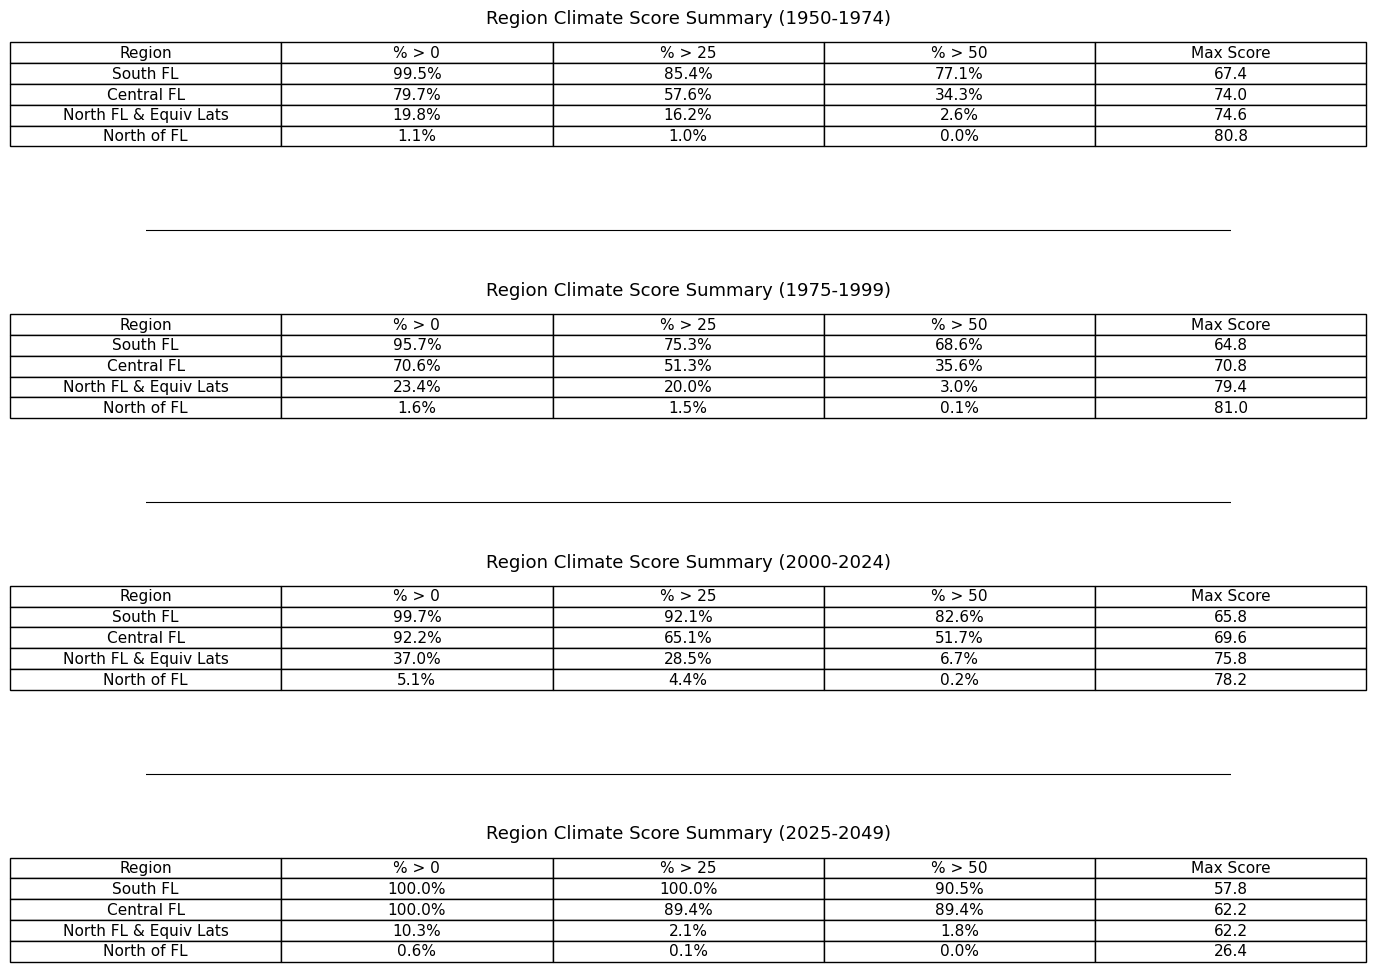

In [24]:
# --- Climate scoring function ---
def citrus_climate_score(row):
    if row['days_below_26F'] > 0 or row['annual_min_temp_F'] < 26:
        return 0
    score = 0
    if row['days_below_32F'] == 0:
        score += 30
    elif row['days_below_32F'] <= 5:
        score += 10
    score += min(row['days_below_55F'] / 5, 40)
    if row['days_below_32F'] == 0 and row['days_below_28F'] == 0:
        score += 20
    return min(score, 100)

# --- Region classification ---
def classify_region(lat):
    if lat < 27: return "South FL"
    elif 27 <= lat < 29.5: return "Central FL"
    elif 29.5 <= lat <= 31: return "North FL & Equiv Lats"
    else: return "North of FL"

region_order = ["South FL","Central FL","North FL & Equiv Lats","North of FL"]

# --- Define time periods ---
time_periods = {
    "1950-1974": (1950, 1974),
    "1975-1999": (1975, 1999),
    "2000-2024": (2000, 2024),
    "2025-2049": (2025, 2049)
}

# --- Assume df exists ---
df['Region'] = df['Lat'].apply(classify_region)
df['climate_score'] = df.apply(citrus_climate_score, axis=1)

# --- Figure: one table per time period, stacked vertically ---
fig = plt.figure(figsize=(14, 12))
outer_gs = gridspec.GridSpec(len(time_periods)*2 - 1, 1, figure=fig, hspace=0.25)

row = 0
for idx, (label, (start, end)) in enumerate(time_periods.items()):
    # Filter period
    mask = (df['Year'] >= start) & (df['Year'] <= end)
    df_period = df.loc[mask].copy()
    df_period['climate_score'] = df_period.apply(citrus_climate_score, axis=1)

    # Region summary
    result = df_period.groupby('Region').agg(
        Percent_above_0=('climate_score', lambda x: (x > 0).mean() * 100),
        Percent_above_25=('climate_score', lambda x: (x > 25).mean() * 100),
        Percent_above_50=('climate_score', lambda x: (x > 50).mean() * 100),
        Max_score=('climate_score', 'max')
    ).reset_index()

    result['Region'] = pd.Categorical(result['Region'], categories=region_order, ordered=True)
    result = result.sort_values('Region')

    # Format percentages
    formatted = result.copy()
    for col in ['Percent_above_0','Percent_above_25','Percent_above_50']:
        formatted[col] = formatted[col].map(lambda x: f"{x:.1f}%")

    # Table axis
    ax = fig.add_subplot(outer_gs[row])
    ax.axis('off')

    table = ax.table(
        cellText=formatted[['Region','Percent_above_0','Percent_above_25','Percent_above_50','Max_score']].values,
        colLabels=['Region','% > 0','% > 25','% > 50','Max Score'],
        cellLoc='center',
        loc='center'
    )
    table.auto_set_font_size(False)
    table.set_fontsize(11)
    table.scale(1.25, 1.25)
    ax.set_title(f"Region Climate Score Summary ({label})", fontsize=13, pad=12)

    # Add separator line between tables (skip after last)
    if idx < len(time_periods) - 1:
        row += 1
        sep_ax = fig.add_subplot(outer_gs[row])
        sep_ax.axis('off')
        # Draw a thin horizontal line across the figure width
        sep_ax.plot([0, 1], [0.5, 0.5], transform=sep_ax.transAxes, color='black', linewidth=0.8)
    row += 1

plt.tight_layout()
plt.show()
